Database connection

In [1]:
import os
from dotenv import load_dotenv, find_dotenv
from sqlalchemy import create_engine
from sqlalchemy.exc import SQLAlchemyError

load_dotenv(find_dotenv())

def connect_to_db():
    host = os.getenv("DB_HOST", "localhost")
    port = os.getenv("DB_PORT", "5432")
    database = os.getenv("DB_NAME")
    user = os.getenv("DB_USER")
    password = os.getenv("DB_PASSWORD")

    if not all([database, user, password]):
        print("Σφάλμα: Δεν βρέθηκαν οι απαραίτητες μεταβλητές στο .env!")
        return None

    try:
        connection_uri = f"postgresql://{user}:{password}@{host}:{port}/{database}"
        engine = create_engine(connection_uri)
        with engine.connect() as connection:
            print(f"Επιτυχής σύνδεση στη βάση '{database}' στο host '{host}'!")
        return engine

    except SQLAlchemyError as e:
        print(f"Σφάλμα κατά τη σύνδεση στη ΒΔ: {e}")
        return None


print("Εκκίνηση σύνδεσης με τη βάση...")
engine = connect_to_db()

if engine is None:
    print("Τερματισμός προγράμματος λόγω αποτυχίας σύνδεσης.")
    exit(1)

Εκκίνηση σύνδεσης με τη βάση...
Επιτυχής σύνδεση στη βάση 'thesis_db' στο host 'dell-micro'!


Import data to dataframe

In [2]:
import pandas as pd

query = "SELECT match_id, x_loc, y_loc, distance_to_goal, angle_to_goal, is_goal FROM understat_shots_normalized"
us_shots = pd.read_sql(query, con=engine)

In [3]:
query = "SELECT match_id, x_loc, y_loc, distance_to_goal, angle_to_goal, is_goal FROM statsbomb_shots_normalized"
sb_shots = pd.read_sql(query, con=engine)

Remove overlapping matches

In [4]:
query = "SELECT understat_match_id FROM mapping_overlapping_matches"
overlapping_matches = pd.read_sql_query(query, con=engine)
overlapping_matches.head()

,understat_match_id
0,923
1,662
2,727
3,890
4,644


In [5]:
print(f"Αρχικές εγγραφές us_shots: {len(us_shots)}")
overlapping_matches_list = overlapping_matches['understat_match_id'].unique()

# Αφαίρεση overlapping matches από το us_shots
us_shots = us_shots[~us_shots['match_id'].isin(overlapping_matches_list)].reset_index(drop=True)

print(f"Overlapping matches: {len(overlapping_matches_list)}")
print(f"Εγγραφές μετά την αφαίρεση: {len(us_shots)}")

Αρχικές εγγραφές us_shots: 605446
Overlapping matches: 1576
Εγγραφές μετά την αφαίρεση: 566725


Drop 'match_id' from DataFrames

In [6]:
us_shots.drop(['match_id'], axis=1, inplace=True)
sb_shots.drop(['match_id'], axis=1, inplace=True)

print(f"{list(us_shots)} και {list(sb_shots)}")

['x_loc', 'y_loc', 'distance_to_goal', 'angle_to_goal', 'is_goal'] και ['x_loc', 'y_loc', 'distance_to_goal', 'angle_to_goal', 'is_goal']


Merge 2 dataframes

In [7]:
shots = pd.concat([us_shots, sb_shots], ignore_index=True)
print(f"Μέγεθος Understat: {len(us_shots)}")
print(f"Μέγεθος StatsBomb: {len(sb_shots)}")
print(f"Μέγεθος Συνολικό : {len(shots)}")

Μέγεθος Understat: 566725
Μέγεθος StatsBomb: 55857
Μέγεθος Συνολικό : 622582


Plot the shots

<Axes: xlabel='x_loc', ylabel='y_loc'>

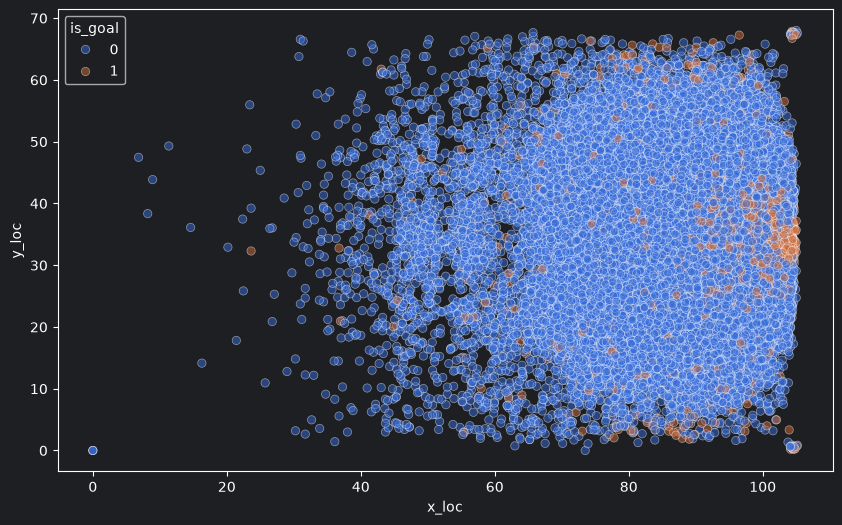

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='x_loc', y='y_loc', data=shots, hue='is_goal', alpha=0.5)

Convert is_goal to boolean

In [9]:
shots.dtypes

x_loc               float64
y_loc               float64
distance_to_goal    float64
angle_to_goal       float64
is_goal               int64
dtype: object

In [10]:
shots['is_goal'] = shots['is_goal'].astype(bool)
shots.dtypes
print(f"Γκολ: {len(shots[shots['is_goal'] == True ])} - ({shots['is_goal'].mean():.2%})")
print(f"Όχι Γκολ: {(~shots['is_goal']).sum()} - ({(~shots['is_goal']).mean():.2%})")
print("Class Imbalanced")

Γκολ: 60584 - (9.73%)
Όχι Γκολ: 561998 - (90.27%)
Class Imbalanced


<Axes: >

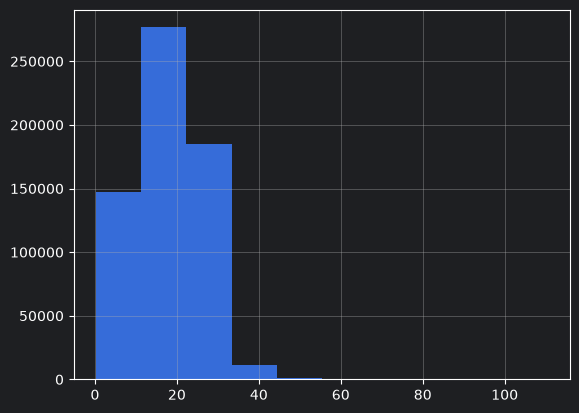

In [11]:
shots['distance_to_goal'].hist()

Model Training

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict

X = shots.drop(columns=['is_goal'])
y = shots['is_goal']

model = DecisionTreeClassifier()
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

predictions = cross_val_predict(model, X, y, cv=skf, method='predict_proba')[:, 1]

Metrics

In [13]:
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss

print("Default settings, 1shot/leaf, τρομερό overfitting")
print(f"Log Loss: {log_loss(y, predictions):.4f}")
print(f"ROC AUC:  {roc_auc_score(y, predictions):.4f}")
print(f"Brier Score:  {brier_score_loss(y, predictions):.04f}")

Default settings, 1shot/leaf, τρομερό overfitting
Log Loss: 2.0257
ROC AUC:  0.6515
Brier Score:  0.1005


Model Training v2

In [14]:
"""
from sklearn.model_selection import GridSearchCV

depth = list(range(3, 10))
min_samples_per_leaf = [1900, 2000, 2100]
model2 = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid = {
        'max_depth': depth,
        'min_samples_leaf': min_samples_per_leaf,
        'criterion':['gini', 'entropy'],
        'ccp_alpha': [0.0, 0.0001, 0.0005, 0.001, 0.005],
        'max_leaf_nodes': [10, 20, 30, 50, 100]
    },
    scoring = 'neg_log_loss',
    cv = skf,
    n_jobs = -1
)

model2.fit(X, y)

print(f"{model2.best_params_}")
"""

print("{'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 9, 'max_leaf_nodes': 50, 'min_samples_leaf': 2000}")

# Best Params:
# {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 9, 'max_leaf_nodes': 50, 'min_samples_leaf': 2000}


{'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 9, 'max_leaf_nodes': 50, 'min_samples_leaf': 2000}


Various testing with GridSearch to find the best parameters for Decision Tree (all commented)

In [15]:
"""
depth = list(range(3, 16))
min_samples_per_leaf = [20, 50, 100, 200, 500]

model2 = GridSearchCV(DecisionTreeClassifier(), param_grid = {'max_depth': depth, 'min_samples_leaf': min_samples_per_leaf}, scoring = 'neg_log_loss', cv = skf, n_jobs = -1)

model2.fit(X, y)

print(f"{model2.best_params_}")
{'max_depth': 7, 'min_samples_leaf': 500}
"""




"""
min_samples_per_leaf = [400, 500, 750, 1000, 1500, 2000]
model2_1 = GridSearchCV(DecisionTreeClassifier(), param_grid = {'max_depth': depth, 'min_samples_leaf': min_samples_per_leaf}, scoring = 'neg_log_loss', cv = skf, n_jobs = -1)

model2_1.fit(X, y)

print(f"{model2_1.best_params_}")
#{'max_depth': 7, 'min_samples_leaf': 2000}
"""




"""
min_samples_per_leaf = [2000, 4000, 6000, 10000, 20000]
model2_2 = GridSearchCV(DecisionTreeClassifier(), param_grid = {'max_depth': depth, 'min_samples_leaf': min_samples_per_leaf}, scoring = 'neg_log_loss', cv = skf, n_jobs = -1)

model2_2.fit(X, y)

print(f"{model2_2.best_params_}")
# {'max_depth': 7, 'min_samples_leaf': 2000}
"""



"""
min_samples_per_leaf = [1900, 2000, 2100]
model2_3 = GridSearchCV(DecisionTreeClassifier(), param_grid = {'max_depth': depth, 'min_samples_leaf': min_samples_per_leaf}, scoring = 'neg_log_loss', cv = skf, n_jobs = -1)

model2_3.fit(X, y)

print(f"{model2_3.best_params_}")
"""

'\nmin_samples_per_leaf = [1900, 2000, 2100]\nmodel2_3 = GridSearchCV(DecisionTreeClassifier(), param_grid = {\'max_depth\': depth, \'min_samples_leaf\': min_samples_per_leaf}, scoring = \'neg_log_loss\', cv = skf, n_jobs = -1)\n\nmodel2_3.fit(X, y)\n\nprint(f"{model2_3.best_params_}")\n'

In [15]:
finalTree = DecisionTreeClassifier(
        max_depth=9,
        min_samples_leaf = 2000,
        criterion='entropy',
        max_leaf_nodes= 50
    )

predictions2 = cross_val_predict(finalTree, X, y, cv = skf, method = 'predict_proba')[:, 1]

In [16]:
print(f"Log Loss: {log_loss(y, predictions2):.4f}")
print(f"ROC AUC:  {roc_auc_score(y, predictions2):.4f}")
print(f"Brier Score:  {brier_score_loss(y, predictions2):.04f}")

Log Loss: 0.2801
ROC AUC:  0.7433
Brier Score:  0.0790


Calibration

In [17]:
from sklearn.calibration import CalibratedClassifierCV

"""
model2_1 = CalibratedClassifierCV(finalTree, method='sigmoid', cv=skf)
predictions2_1 = cross_val_predict(model2_1, X, y, cv = skf, method = 'predict_proba')[:, 1]

print(f"Log Loss: {log_loss(y, predictions2_1):.4f}")
print(f"ROC AUC:  {roc_auc_score(y, predictions2_1):.4f}")
print(f"Brier Score:  {brier_score_loss(y, predictions2_1):.04f}")
"""

model2Calibrated = CalibratedClassifierCV(finalTree, method='isotonic', cv=skf)
predictions2Calibrated = cross_val_predict(model2Calibrated, X, y, cv = skf, method = 'predict_proba')[:, 1]

print(f"Log Loss: {log_loss(y, predictions2Calibrated):.4f}")
print(f"ROC AUC:  {roc_auc_score(y, predictions2Calibrated):.4f}")
print(f"Brier Score:  {brier_score_loss(y, predictions2Calibrated):.04f}")

Log Loss: 0.2800
ROC AUC:  0.7439
Brier Score:  0.0790


In [18]:
finalCalibratedTree = CalibratedClassifierCV(
    estimator=finalTree, method="isotonic", cv=skf
)

finalCalibratedTree.fit(X, y)
fitted_tree = finalCalibratedTree.calibrated_classifiers_[0].estimator

Tree visualization

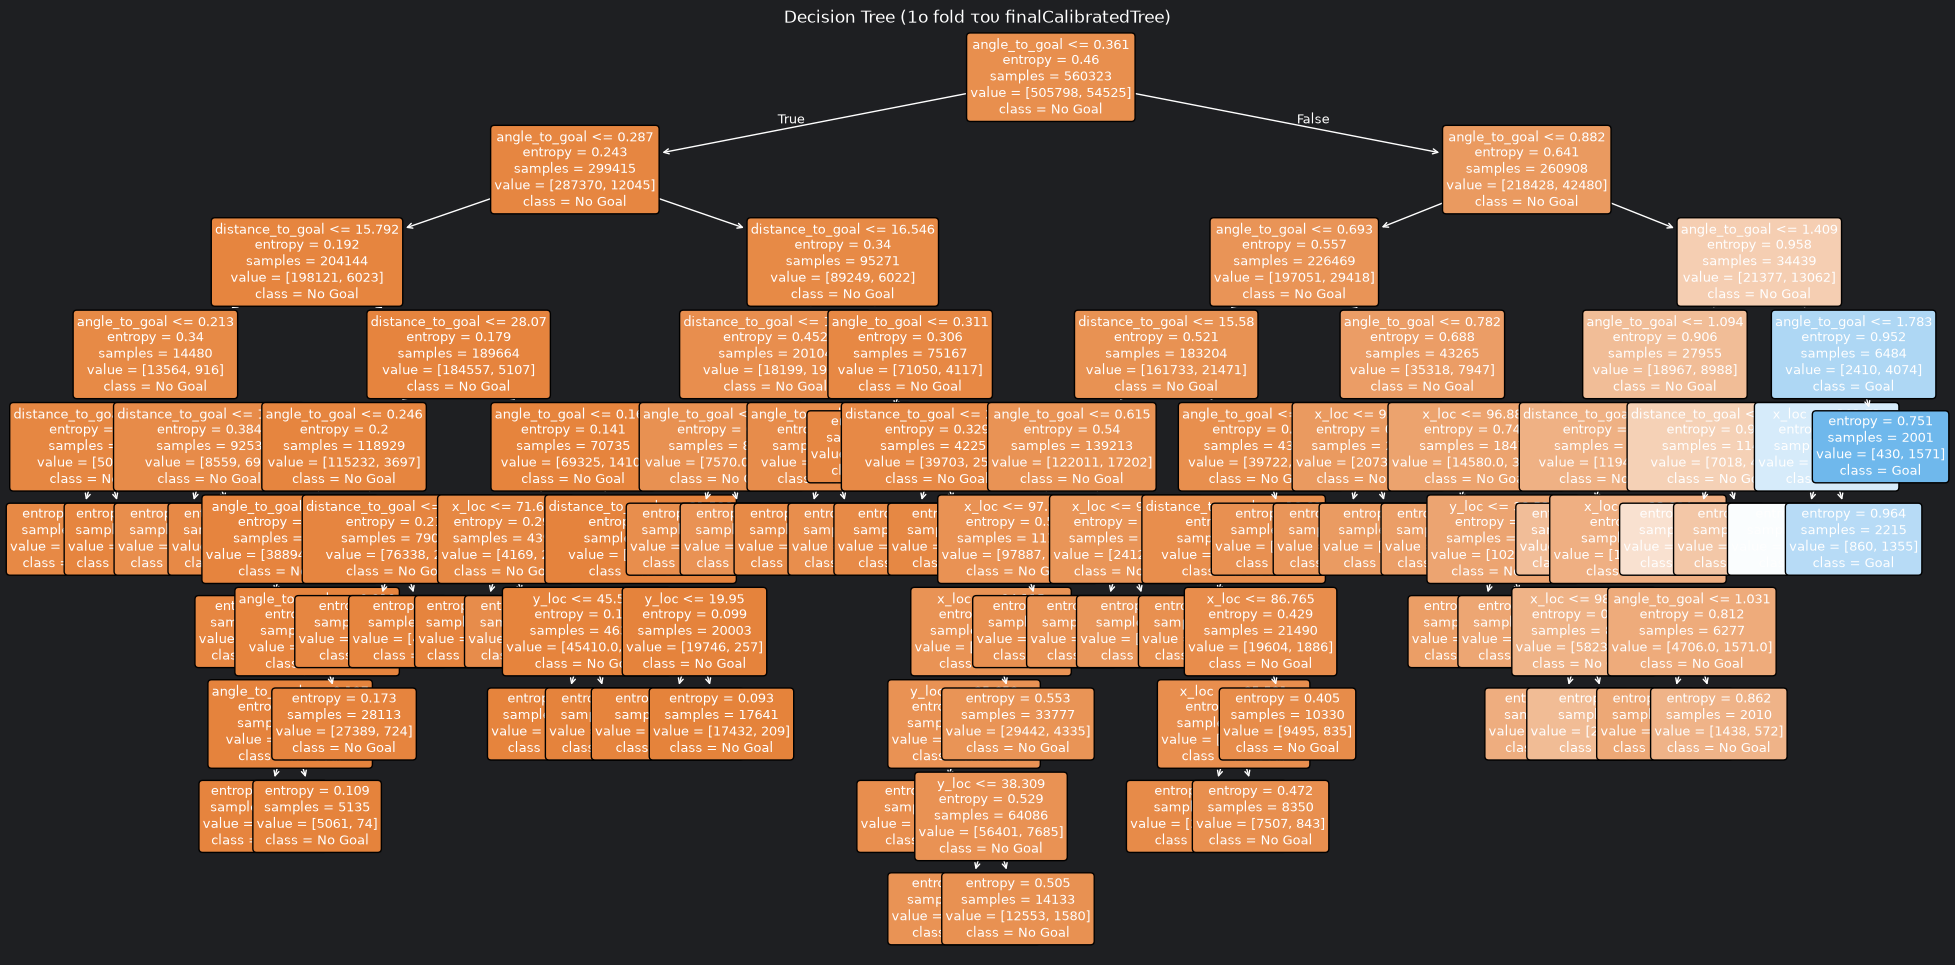

In [19]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))
plot_tree(
    fitted_tree,
    feature_names=X.columns if hasattr(X, "columns") else None,
    class_names=["No Goal", "Goal"],
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("Decision Tree (1ο fold του finalCalibratedTree)")
plt.show()

Importance

In [20]:
import numpy as np

all_importances = []

# Ποσοστά importance των μεταβλητών από κάθε δέντρο (10 δέντρα, όσα και τα folds)
for pair in finalCalibratedTree.calibrated_classifiers_:
    tree = pair.estimator
    importance_values = tree.feature_importances_
    all_importances.append(importance_values)


mean_importance = np.mean(all_importances, axis=0) * 100
std_importance = np.std(all_importances, axis=0) * 100

feature_names = X.columns
feature_importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance (%)": mean_importance,
        "Std (%)": std_importance,
    }
)
feature_importance_df = feature_importance_df.sort_values(by="Importance (%)", ascending=False)

print("Feature Importances (%) (Std Deviation %):")
for feature, importance, std in feature_importance_df.values:
    print(f"- {feature:<18} : {importance:>6.2f}% (±{std:>5.2f}%)")

Feature Importances (%) (Std Deviation %):
- angle_to_goal      :  91.31% (± 1.38%)
- distance_to_goal   :   7.98% (± 1.43%)
- x_loc              :   0.58% (± 0.08%)
- y_loc              :   0.14% (± 0.05%)


xG Heatmap

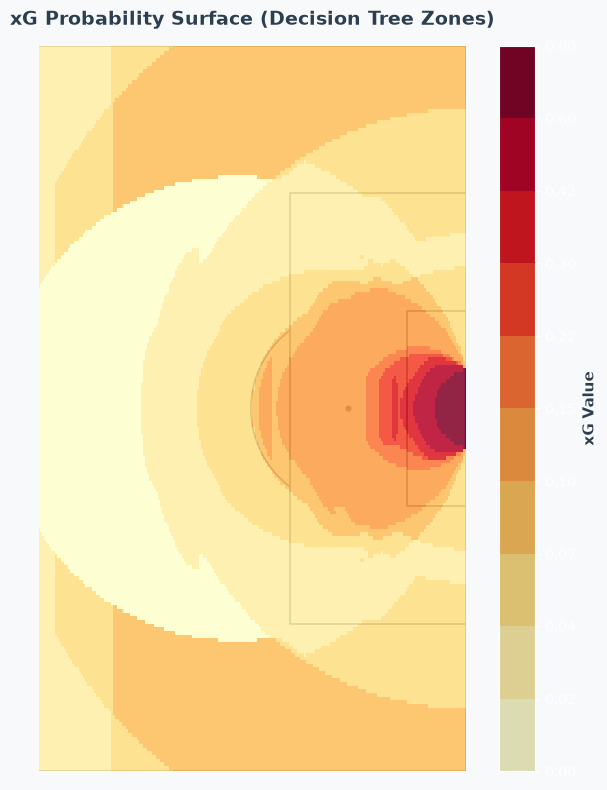

In [25]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

# 1. Πλέγμα στο επιθετικό μισό (65 έως 105 στο μήκος, 0 έως 68 στο πλάτος)
x_coords = np.linspace(65, 105, 200)
y_coords = np.linspace(0, 68, 200)
grid_x, grid_y = np.meshgrid(x_coords, y_coords)

flat_x = grid_x.ravel()
flat_y = grid_y.ravel()

# 2. Γεωμετρία εστίας (x=105, κέντρο y=34, δοκάρια y=30.34 & 37.66)
goal_x = 105.0
goal_y = 34.0
y1, y2 = 30.34, 37.66

# Απόσταση από το κέντρο της γραμμής τέρματος
dist_grid = np.sqrt((goal_x - flat_x)**2 + (flat_y - goal_y)**2)

# Ορατή γωνία προς τα δοκάρια σε ακτίνια (όπως στα δεδομένα σου)
v1 = np.column_stack([goal_x - flat_x, y1 - flat_y])
v2 = np.column_stack([goal_x - flat_x, y2 - flat_y])
cos_theta = np.sum(v1 * v2, axis=1) / (np.linalg.norm(v1, axis=1) * np.linalg.norm(v2, axis=1) + 1e-9)
angle_grid = np.arccos(np.clip(cos_theta, -1.0, 1.0))

# 3. Features για το μοντέλο
grid_features = pd.DataFrame({
    'x_loc': flat_x,
    'y_loc': flat_y,
    'distance_to_goal': dist_grid,
    'angle_to_goal': angle_grid
})[X.columns]

# 4. Πρόβλεψη xG
tree_grid_xg = finalCalibratedTree.predict_proba(grid_features)[:, 1].reshape(grid_x.shape)

# 5. Διακριτά bins χρωμάτων ώστε να φαίνονται οι ζώνες ακόμα και στα χαμηλά xG
bounds = [0.0, 0.02, 0.04, 0.07, 0.10, 0.15, 0.22, 0.30, 0.42, 0.60, 0.80]
cmap = plt.get_cmap('YlOrRd')  # Από απαλό κίτρινο σε βαθύ κόκκινο
norm = BoundaryNorm(bounds, cmap.N)

# 6. Σχεδιασμός σε οριζόντιο γήπεδο
pitch = Pitch(
    pitch_type='custom',
    pitch_length=105,
    pitch_width=68,
    line_color='#2c3e50',
    pitch_color='#f8f9fa',
    linewidth=1.2
)

fig, ax = plt.subplots(figsize=(12, 8), facecolor='#f8f9fa')
pitch.draw(ax=ax)

# Χρήση pcolormesh με το διακριτό colormap για να αναδειχθούν τα "blocks" του Decision Tree
mesh = ax.pcolormesh(
    grid_x, grid_y, tree_grid_xg,
    cmap=cmap,
    norm=norm,
    alpha=0.85,
    shading='auto'
)

# Όρια εμφάνισης (επιθετικό μισό)
ax.set_xlim(65, 105)
ax.set_ylim(0, 68)

ax.set_title("xG Probability Surface (Decision Tree Zones)", fontsize=14, pad=15, weight='bold', color='#2c3e50')

# Colorbar με ρητές τιμές
cbar = fig.colorbar(mesh, ax=ax, fraction=0.035, pad=0.03, ticks=bounds)
cbar.set_label('xG Value', size=11, weight='bold', color='#2c3e50')
cbar.ax.set_yticklabels([f"{b:.2f}" for b in bounds])

plt.tight_layout()
plt.show()

Calibration Curve

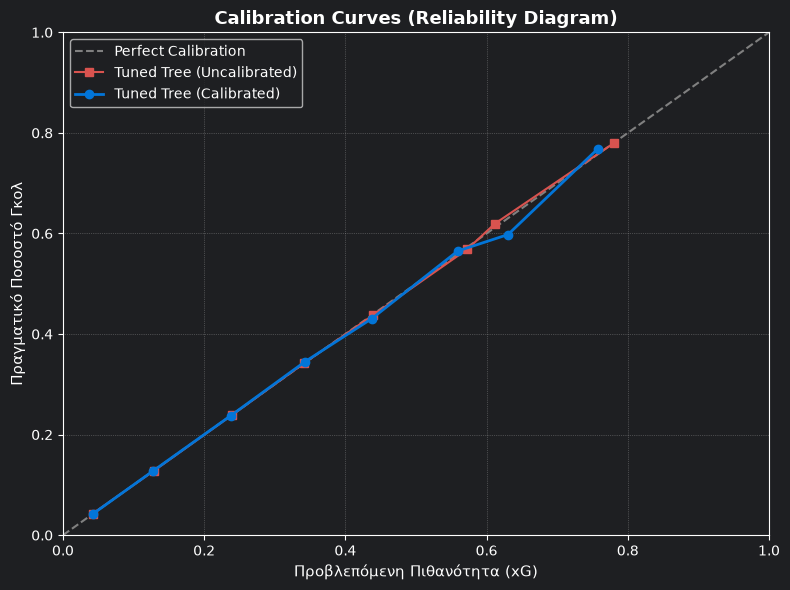

In [29]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true_tree, prob_pred_tree = calibration_curve(y, predictions2, n_bins=10, strategy='uniform')
prob_true_cal, prob_pred_cal = calibration_curve(y, predictions2Calibrated, n_bins=10, strategy='uniform')

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.plot(prob_pred_tree, prob_true_tree, marker='s', linewidth=1.5, color='#d9534f', label='Tuned Tree (Uncalibrated)')
plt.plot(prob_pred_cal, prob_true_cal, marker='o', linewidth=2, color='#0275d8', label='Tuned Tree (Calibrated)')

plt.xlabel('Προβλεπόμενη Πιθανότητα (xG)', fontsize=11)
plt.ylabel('Πραγματικό Ποσοστό Γκολ', fontsize=11)
plt.title('Calibration Curves (Reliability Diagram)', fontsize=13, weight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()